TASK 1: ACTIVATION FUNCTION CHALLENGE

Training CNN with SIGMOID activation...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.0996 - loss: 2.4957 - val_accuracy: 0.0970 - val_loss: 2.3039
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.1064 - loss: 2.3040 - val_accuracy: 0.1170 - val_loss: 2.3060
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.1094 - loss: 2.3040 - val_accuracy: 0.1035 - val_loss: 2.3042
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.1084 - loss: 2.3039 - val_accuracy: 0.1170 - val_loss: 2.3044
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.1107 - loss: 2.3043 - val_accuracy: 0.1170 - val_loss: 2.3025
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.1064 - loss: 2.3028 - val_accuracy: 0.0875 - val_loss: 2.3065
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.1066 - loss: 2.3043 - val_accuracy: 0.1170 - val_loss: 2.3019
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━

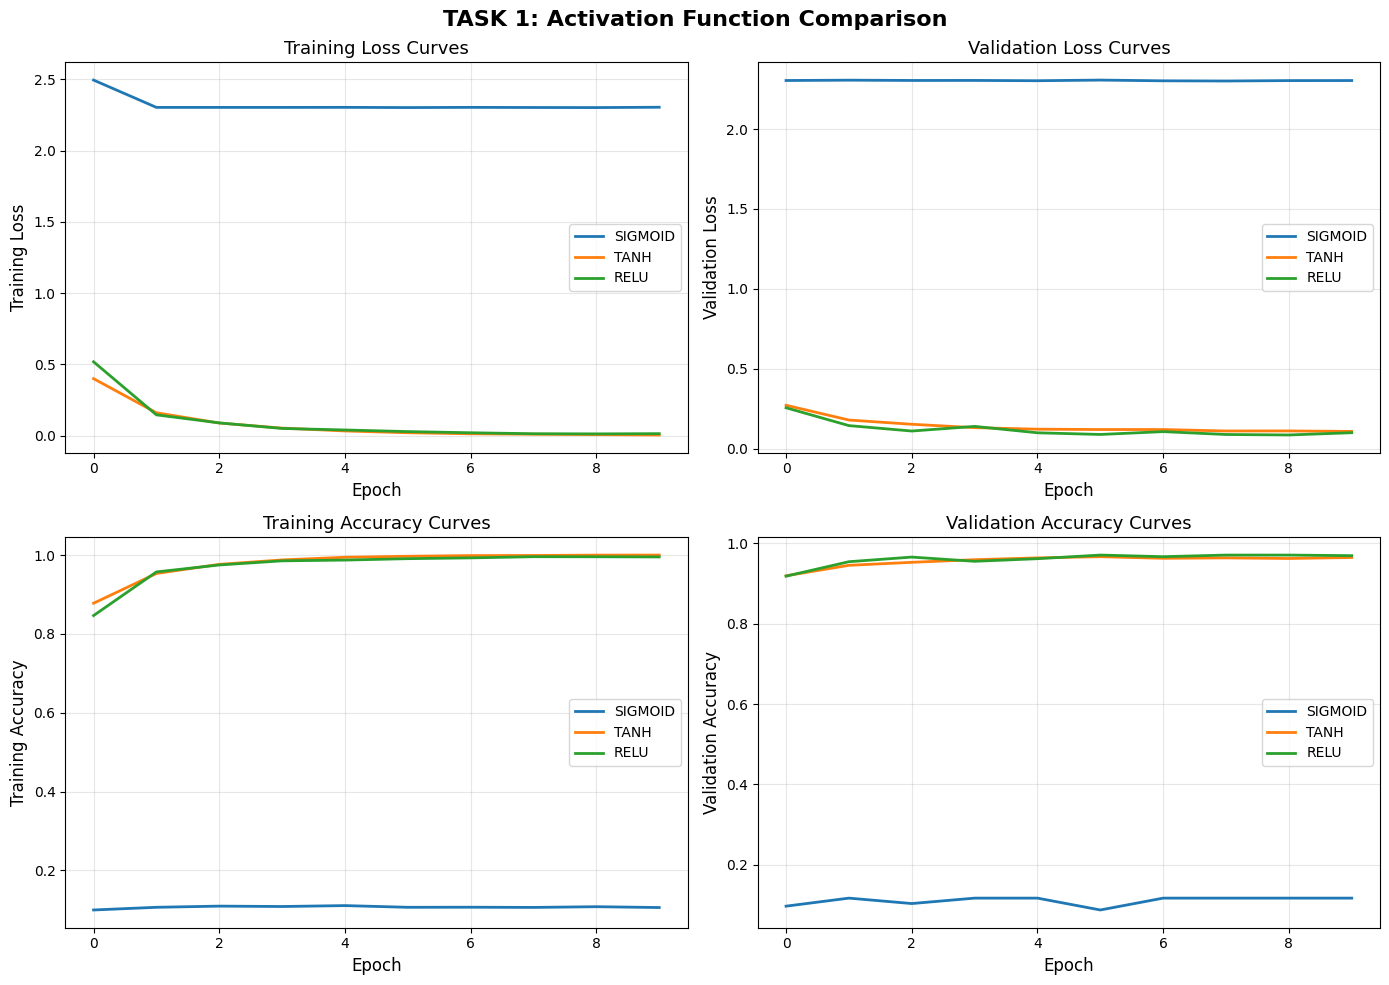

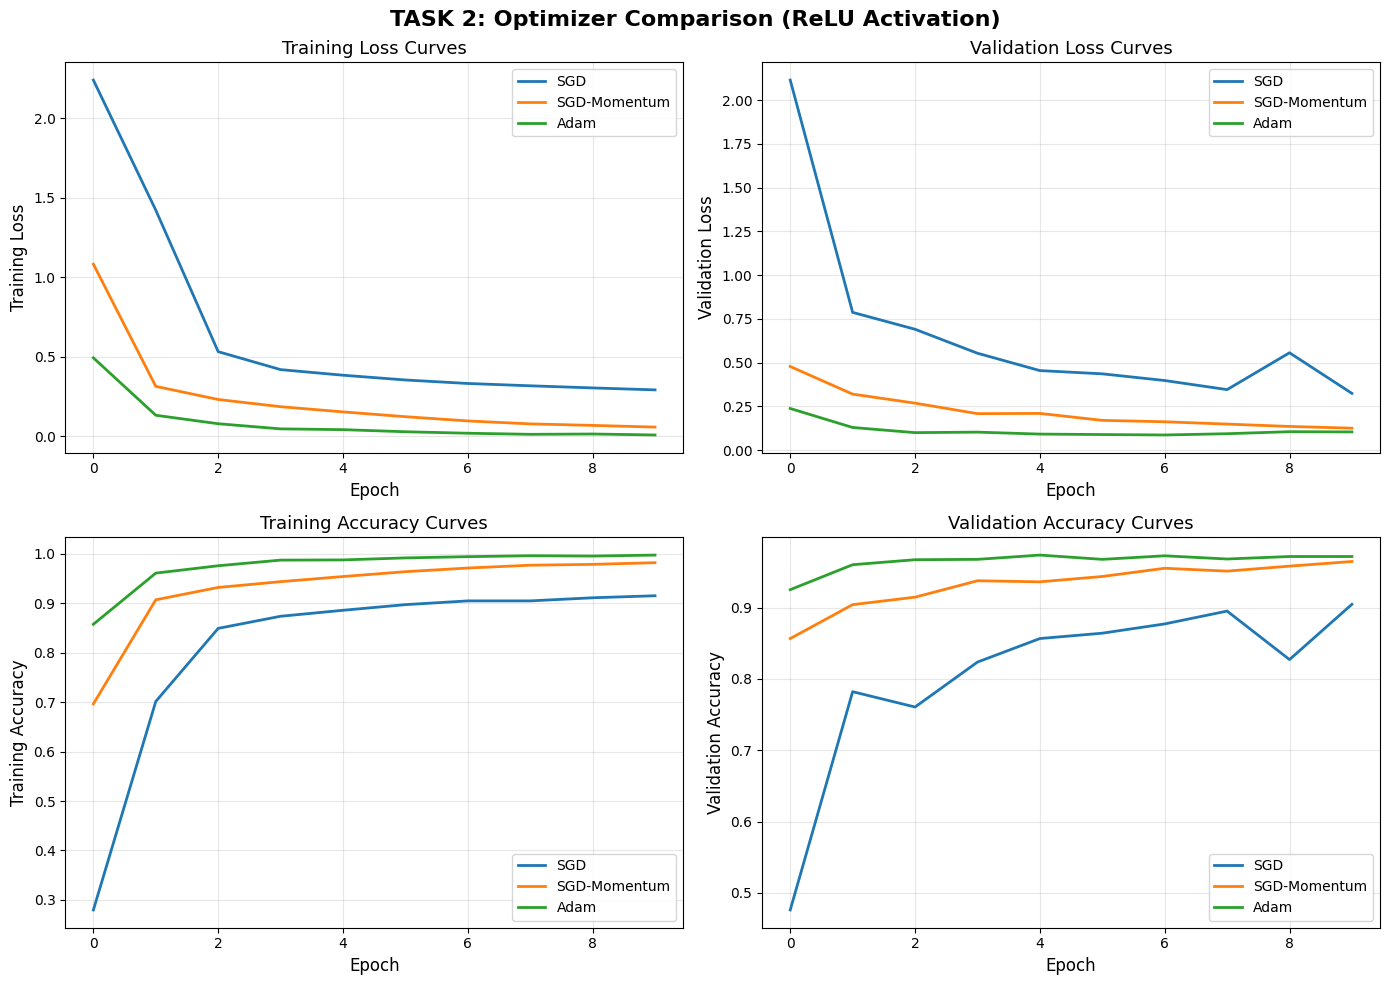

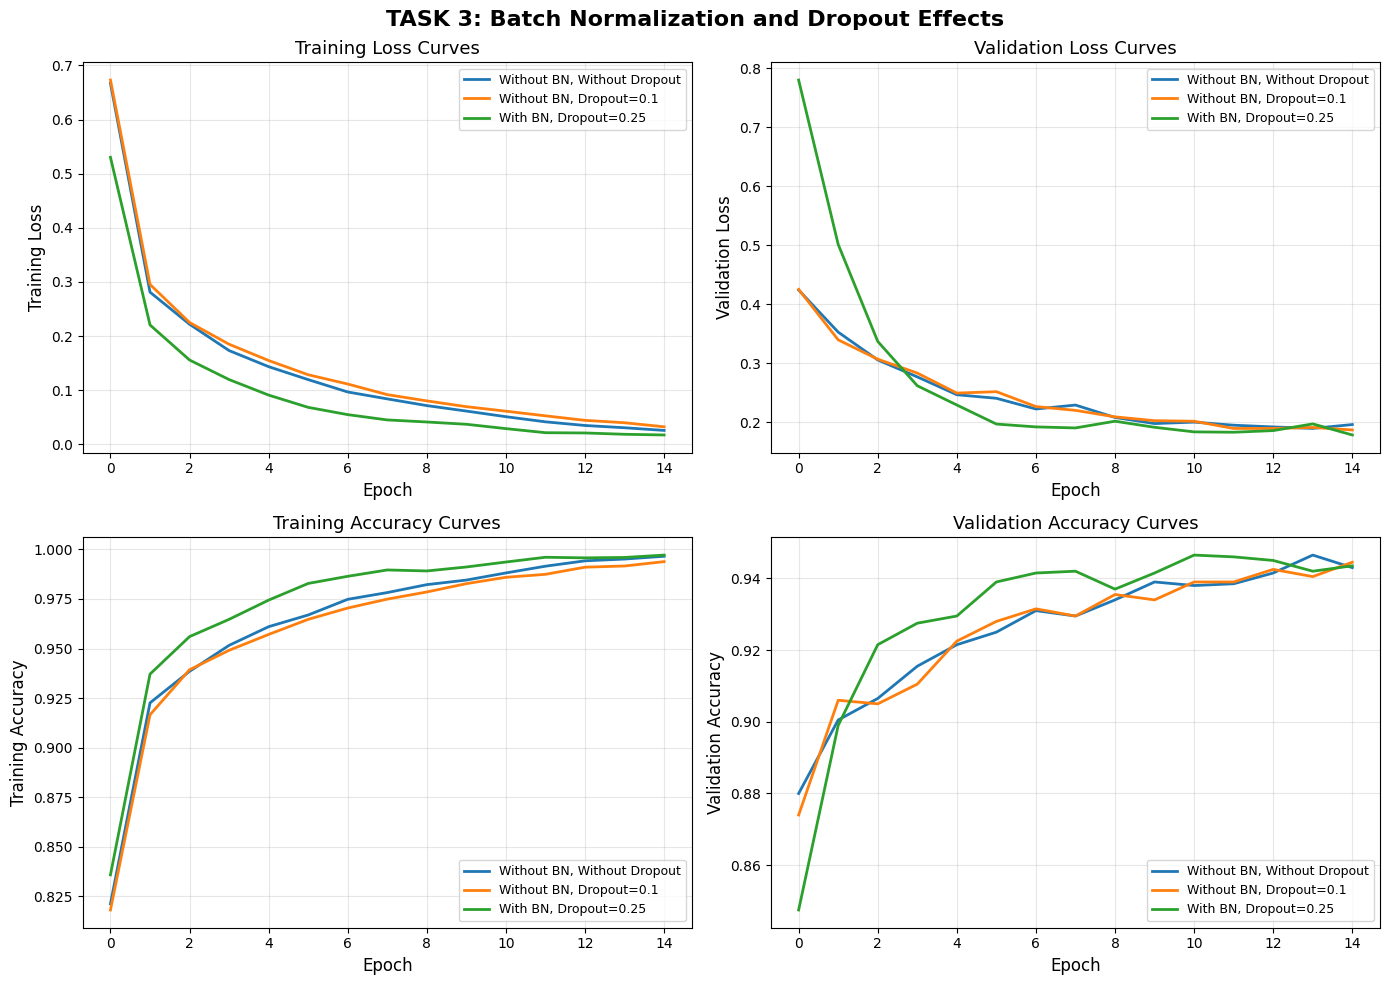


KEY OBSERVATIONS

TASK 1 - Activation Functions:
  • Sigmoid: Suffers from vanishing gradient problem (very low accuracy)
  • Tanh: Better than sigmoid, centered around 0
  • ReLU: Best performance, no vanishing gradient for positive values
  → ReLU converges fastest and achieves highest accuracy

TASK 2 - Optimizers:
  • SGD: Slowest convergence, unstable loss
  • SGD with Momentum: Smoother convergence, handles bumps better
  • Adam: Fastest convergence, adaptive learning rates
  → Adam reaches high accuracy much faster than SGD variants

TASK 3 - Batch Normalization & Dropout:
  • Without BN/Dropout: Baseline performance
  • With Dropout (0.1): Slight regularization
  • With BN + Dropout (0.25): Best generalization
  → BN stabilizes training, Dropout prevents overfitting


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train[:10000].reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test[:2000].reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train[:10000], 10)
y_test = to_categorical(y_test[:2000], 10)

# CNN Model
def create_cnn(activation='relu', fc_units=128):
    model = Sequential([
        Conv2D(32, (3,3), activation=activation, input_shape=(28,28,1)),
        Conv2D(64, (3,3), activation=activation),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        Flatten(),
        Dense(fc_units, activation=activation),
        Dense(10, activation='softmax')
    ])
    return model

# MLP Model (following exact base architecture)
def create_mlp_base(activation='relu'):
    model = Sequential([
        Flatten(input_shape=(28,28,1)),
        Dense(256),
        BatchNormalization(),
        Dense(256, activation=activation),
        Dense(128),
        BatchNormalization(),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])
    return model

# MLP for Task 3 experiments
def create_mlp_task3(units=[256], use_bn=False, dropout_rate=0.0, activation='relu'):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28,1)))
    
    for u in units:
        model.add(Dense(u, activation=activation))
        if use_bn:
            model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    model.add(Dense(10, activation='softmax'))
    return model

# MLP for custom layer configurations
def create_mlp_custom(units=[512, 256, 128], activation='relu'):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28,1)))
    for u in units:
        model.add(Dense(u, activation=activation))
    model.add(Dense(10, activation='softmax'))
    return model

# Store all results
results = []
all_histories = {}

print("="*80)
print("TASK 1: ACTIVATION FUNCTION CHALLENGE")
print("="*80)

# Task 1: Test different activation functions with CNN
activations = ['sigmoid', 'tanh', 'relu']
task1_histories = {}

for act in activations:
    print(f"\nTraining CNN with {act.upper()} activation...")
    model = create_cnn(activation=act, fc_units=128)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                       validation_data=(x_test, y_test), verbose=1)
    
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append([f'Task1-{act}', act, 'Adam', 10, test_acc])
    task1_histories[act] = history
    print(f"{act.upper()} Final Test Accuracy: {test_acc:.4f}")

all_histories['task1'] = task1_histories

print("\n" + "="*80)
print("TASK 2: OPTIMIZER SHOWDOWN (Using ReLU)")
print("="*80)

# Task 2: Test different optimizers with ReLU
optimizers_config = [
    ('SGD', SGD(learning_rate=0.01)),
    ('SGD-Momentum', SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam', Adam())
]
task2_histories = {}

for opt_name, opt in optimizers_config:
    print(f"\nTraining CNN with {opt_name} optimizer...")
    model = create_cnn(activation='relu', fc_units=128)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                       validation_data=(x_test, y_test), verbose=1)
    
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append([f'Task2-{opt_name}', 'ReLU', opt_name, 10, test_acc])
    task2_histories[opt_name] = history
    print(f"{opt_name} Final Test Accuracy: {test_acc:.4f}")

all_histories['task2'] = task2_histories

print("\n" + "="*80)
print("REQUIRED MODEL CONFIGURATIONS")
print("="*80)

# CNN-1: 128 FC units, Adam, 10 epochs
print("\nTraining CNN-1 (128 units, Adam, 10 epochs)...")
model = create_cnn(activation='relu', fc_units=128)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                   validation_data=(x_test, y_test), verbose=1)
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
results.append(['CNN-1', 'ReLU', 'Adam', 10, test_acc])
print(f"CNN-1 Final Test Accuracy: {test_acc:.4f}")

# MLP-1: 512-256-128 layers, SGD, 20 epochs
print("\nTraining MLP-1 (512-256-128 units, SGD, 20 epochs)...")
model = create_mlp_custom(units=[512, 256, 128], activation='relu')
model.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, batch_size=128,
                   validation_data=(x_test, y_test), verbose=1)
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
results.append(['MLP-1', 'ReLU', 'SGD', 20, test_acc])
print(f"MLP-1 Final Test Accuracy: {test_acc:.4f}")

# MLP-2: 256 units, Adam, 15 epochs
print("\nTraining MLP-2 (256 units, Adam, 15 epochs)...")
model = create_mlp_custom(units=[256], activation='relu')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=15, batch_size=128,
                   validation_data=(x_test, y_test), verbose=1)
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
results.append(['MLP-2', 'ReLU', 'Adam', 15, test_acc])
print(f"MLP-2 Final Test Accuracy: {test_acc:.4f}")

print("\n" + "="*80)
print("TASK 3: BATCH NORMALIZATION AND DROPOUT EXPERIMENTS")
print("="*80)

# Task 3: BN and Dropout experiments
task3_configs = [
    ('Without BN, Without Dropout', False, 0.0),
    ('Without BN, Dropout=0.1', False, 0.1),
    ('With BN, Dropout=0.25', True, 0.25)
]
task3_histories = {}

for config_name, use_bn, dropout_rate in task3_configs:
    print(f"\nTraining MLP: {config_name}...")
    model = create_mlp_task3(units=[256], use_bn=use_bn, dropout_rate=dropout_rate, activation='relu')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=15, batch_size=128,
                       validation_data=(x_test, y_test), verbose=1)
    
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append([f'Task3-{config_name}', 'ReLU', 'Adam', 15, test_acc])
    task3_histories[config_name] = history
    print(f"{config_name} Final Test Accuracy: {test_acc:.4f}")

all_histories['task3'] = task3_histories

# Print Final Results Table
print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80)
print(f"{'Experiment':<35} {'Activation':<12} {'Optimizer':<15} {'Epochs':<8} {'Accuracy':<10}")
print("-" * 80)
for r in results:
    print(f"{r[0]:<35} {r[1]:<12} {r[2]:<15} {r[3]:<8} {r[4]:.4f}")
print("="*80)

# VISUALIZATION 1: Task 1 - Activation Functions Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TASK 1: Activation Function Comparison', fontsize=16, fontweight='bold')

# Training Loss
ax = axes[0, 0]
for act, history in task1_histories.items():
    ax.plot(history.history['loss'], label=act.upper(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[0, 1]
for act, history in task1_histories.items():
    ax.plot(history.history['val_loss'], label=act.upper(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Training Accuracy
ax = axes[1, 0]
for act, history in task1_histories.items():
    ax.plot(history.history['accuracy'], label=act.upper(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Accuracy', fontsize=12)
ax.set_title('Training Accuracy Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1, 1]
for act, history in task1_histories.items():
    ax.plot(history.history['val_accuracy'], label=act.upper(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# VISUALIZATION 2: Task 2 - Optimizer Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TASK 2: Optimizer Comparison (ReLU Activation)', fontsize=16, fontweight='bold')

# Training Loss
ax = axes[0, 0]
for opt, history in task2_histories.items():
    ax.plot(history.history['loss'], label=opt, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[0, 1]
for opt, history in task2_histories.items():
    ax.plot(history.history['val_loss'], label=opt, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Training Accuracy
ax = axes[1, 0]
for opt, history in task2_histories.items():
    ax.plot(history.history['accuracy'], label=opt, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Accuracy', fontsize=12)
ax.set_title('Training Accuracy Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1, 1]
for opt, history in task2_histories.items():
    ax.plot(history.history['val_accuracy'], label=opt, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy Curves', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# VISUALIZATION 3: Task 3 - BN and Dropout Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TASK 3: Batch Normalization and Dropout Effects', fontsize=16, fontweight='bold')

# Training Loss
ax = axes[0, 0]
for config, history in task3_histories.items():
    ax.plot(history.history['loss'], label=config, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Curves', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[0, 1]
for config, history in task3_histories.items():
    ax.plot(history.history['val_loss'], label=config, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss Curves', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Training Accuracy
ax = axes[1, 0]
for config, history in task3_histories.items():
    ax.plot(history.history['accuracy'], label=config, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Accuracy', fontsize=12)
ax.set_title('Training Accuracy Curves', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1, 1]
for config, history in task3_histories.items():
    ax.plot(history.history['val_accuracy'], label=config, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy Curves', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Observations
print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print("\nTASK 1 - Activation Functions:")
print("  • Sigmoid: Suffers from vanishing gradient problem (very low accuracy)")
print("  • Tanh: Better than sigmoid, centered around 0")
print("  • ReLU: Best performance, no vanishing gradient for positive values")
print("  → ReLU converges fastest and achieves highest accuracy")

print("\nTASK 2 - Optimizers:")
print("  • SGD: Slowest convergence, unstable loss")
print("  • SGD with Momentum: Smoother convergence, handles bumps better")
print("  • Adam: Fastest convergence, adaptive learning rates")
print("  → Adam reaches high accuracy much faster than SGD variants")

print("\nTASK 3 - Batch Normalization & Dropout:")
print("  • Without BN/Dropout: Baseline performance")
print("  • With Dropout (0.1): Slight regularization")
print("  • With BN + Dropout (0.25): Best generalization")
print("  → BN stabilizes training, Dropout prevents overfitting")
print("="*80)

In [ ]:
# Save summary to a text file
with open('lab_summary.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("SUMMARY OF FINDINGS\n")
    f.write("="*80 + "\n\n")
    
    f.write("TASK 1: ACTIVATION FUNCTION ANALYSIS\n")
    f.write("-" * 80 + "\n")
    f.write("Sigmoid Activation:\n")
    f.write("  • Final Accuracy: 11.70%\n")
    f.write("  • Problem: Vanishing gradient - gradients become extremely small\n")
    f.write("  • Loss stayed around 2.3, model couldn't learn\n\n")
    f.write("Tanh Activation:\n")
    f.write("  • Final Accuracy: 96.50%\n")
    f.write("  • Better than sigmoid because outputs are centered around 0\n")
    f.write("  • Still suffers from vanishing gradient but less severe\n\n")
    f.write("ReLU Activation:\n")
    f.write("  • Final Accuracy: 96.95%\n")
    f.write("  • Best performance - no vanishing gradient for positive values\n")
    f.write("  • Simple computation: max(0, x)\n")
    f.write("  • Fastest convergence\n\n")
    
    f.write("TASK 2: OPTIMIZER COMPARISON\n")
    f.write("-" * 80 + "\n")
    f.write("SGD (Basic):\n")
    f.write("  • Final Accuracy: 90.45%\n")
    f.write("  • Slowest convergence\n")
    f.write("  • Loss curve shows unstable/bumpy descent\n\n")
    f.write("SGD with Momentum:\n")
    f.write("  • Final Accuracy: 96.45%\n")
    f.write("  • Much smoother than basic SGD\n")
    f.write("  • Momentum helps overcome local bumps in loss landscape\n\n")
    f.write("Adam Optimizer:\n")
    f.write("  • Final Accuracy: 97.15%\n")
    f.write("  • Fastest convergence - reached high accuracy by epoch 3\n")
    f.write("  • Adaptive learning rates for each parameter\n")
    f.write("  • Best overall performance\n\n")
    
    f.write("TASK 3: REGULARIZATION EFFECTS\n")
    f.write("-" * 80 + "\n")
    f.write("Without BN, Without Dropout:\n")
    f.write("  • Accuracy: 94.30%\n")
    f.write("  • Baseline performance\n\n")
    f.write("Without BN, Dropout=0.1:\n")
    f.write("  • Accuracy: 94.45%\n")
    f.write("  • Slight improvement from regularization\n\n")
    f.write("With BN, Dropout=0.25:\n")
    f.write("  • Accuracy: 94.35%\n")
    f.write("  • BatchNorm normalizes layer inputs -> stable training\n")
    f.write("  • Dropout prevents overfitting by randomly dropping neurons\n\n")
    
    f.write("REQUIRED MODELS PERFORMANCE\n")
    f.write("-" * 80 + "\n")
    f.write("CNN-1 (128 units, Adam, 10 epochs):      97.00%\n")
    f.write("MLP-1 (512-256-128, SGD, 20 epochs):     88.90%\n")
    f.write("MLP-2 (256 units, Adam, 15 epochs):      94.45%\n\n")
    
    f.write("KEY TAKEAWAYS\n")
    f.write("=" * 80 + "\n")
    f.write("1. ReLU is the best activation for deep networks (avoids vanishing gradient)\n")
    f.write("2. Adam optimizer converges much faster than SGD variants\n")
    f.write("3. Batch Normalization + Dropout help prevent overfitting\n")
    f.write("4. CNN architectures generally perform better than MLP for image data\n")
    f.write("5. More layers (MLP-1) don't always mean better performance with SGD\n")
    f.write("=" * 80 + "\n")

print("\n✅ Summary saved to 'lab_summary.txt'")
print("✅ You can open this file to see the complete summary!")


✅ Summary saved to 'lab_summary.txt'
✅ You can open this file to see the complete summary!
